# 🌸 Iris Flower Classification using Machine Learning

## Project Overview

This project aims to build a Machine Learning model that can accurately classify Iris flowers into three different species based on their flower measurements.

The model is trained using the famous Iris dataset and learns patterns from four flower features to predict the species of a new flower.

This project demonstrates a complete Machine Learning workflow, including data loading, data exploration, visualization, model training, evaluation, prediction, and model saving.

## Step 1: Import Required Libraries

In [22]:
# ==============================
# Data Manipulation Libraries
# ==============================

import pandas as pd
import numpy as np

# ==============================
# Data Visualization Libraries
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Machine Learning Libraries
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# ==============================
# Model Evaluation
# ==============================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ==============================
# Ignore Warnings
# ==============================

import warnings
warnings.filterwarnings("ignore")

## Step 2: Load the Dataset

In [23]:
# Load the Iris dataset

df = pd.read_csv("Iris.csv")

# Display the first five rows

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Step 3: Understand the Dataset

In [24]:
# Display dataset shape
print("Dataset Shape:", df.shape)

print("\n" + "="*50)

# Display column names
print("Column Names:")
print(df.columns)

print("\n" + "="*50)

# Display dataset information
print("Dataset Information:")
df.info()

print("\n" + "="*50)

# Display statistical summary
print("Statistical Summary:")
print(df.describe())

print("\n" + "="*50)

# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Dataset Shape: (150, 6)

Column Names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB

Statistical Summary:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.

### Insight

The Iris dataset contains measurements of iris flowers belonging to three different species. The dataset consists of numerical features and does not contain any missing values, making it suitable for machine learning classification.

## Step 4: Exploratory Data Analysis (EDA)

In [25]:
# Display the number of samples in each species

df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

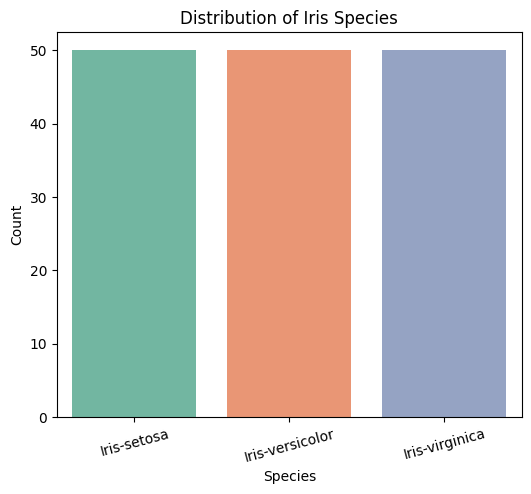

In [26]:
# Visualize the distribution of flower species

plt.figure(figsize=(6,5))

sns.countplot(
    x="Species",
    data=df,
    palette="Set2"
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.xticks(rotation=15)

plt.show()

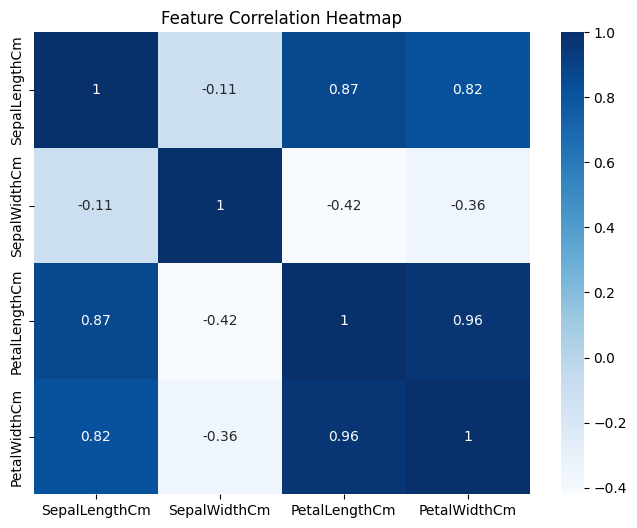

In [27]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

numeric_df = df.drop(columns=["Id", "Species"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Feature Correlation Heatmap")

plt.show()

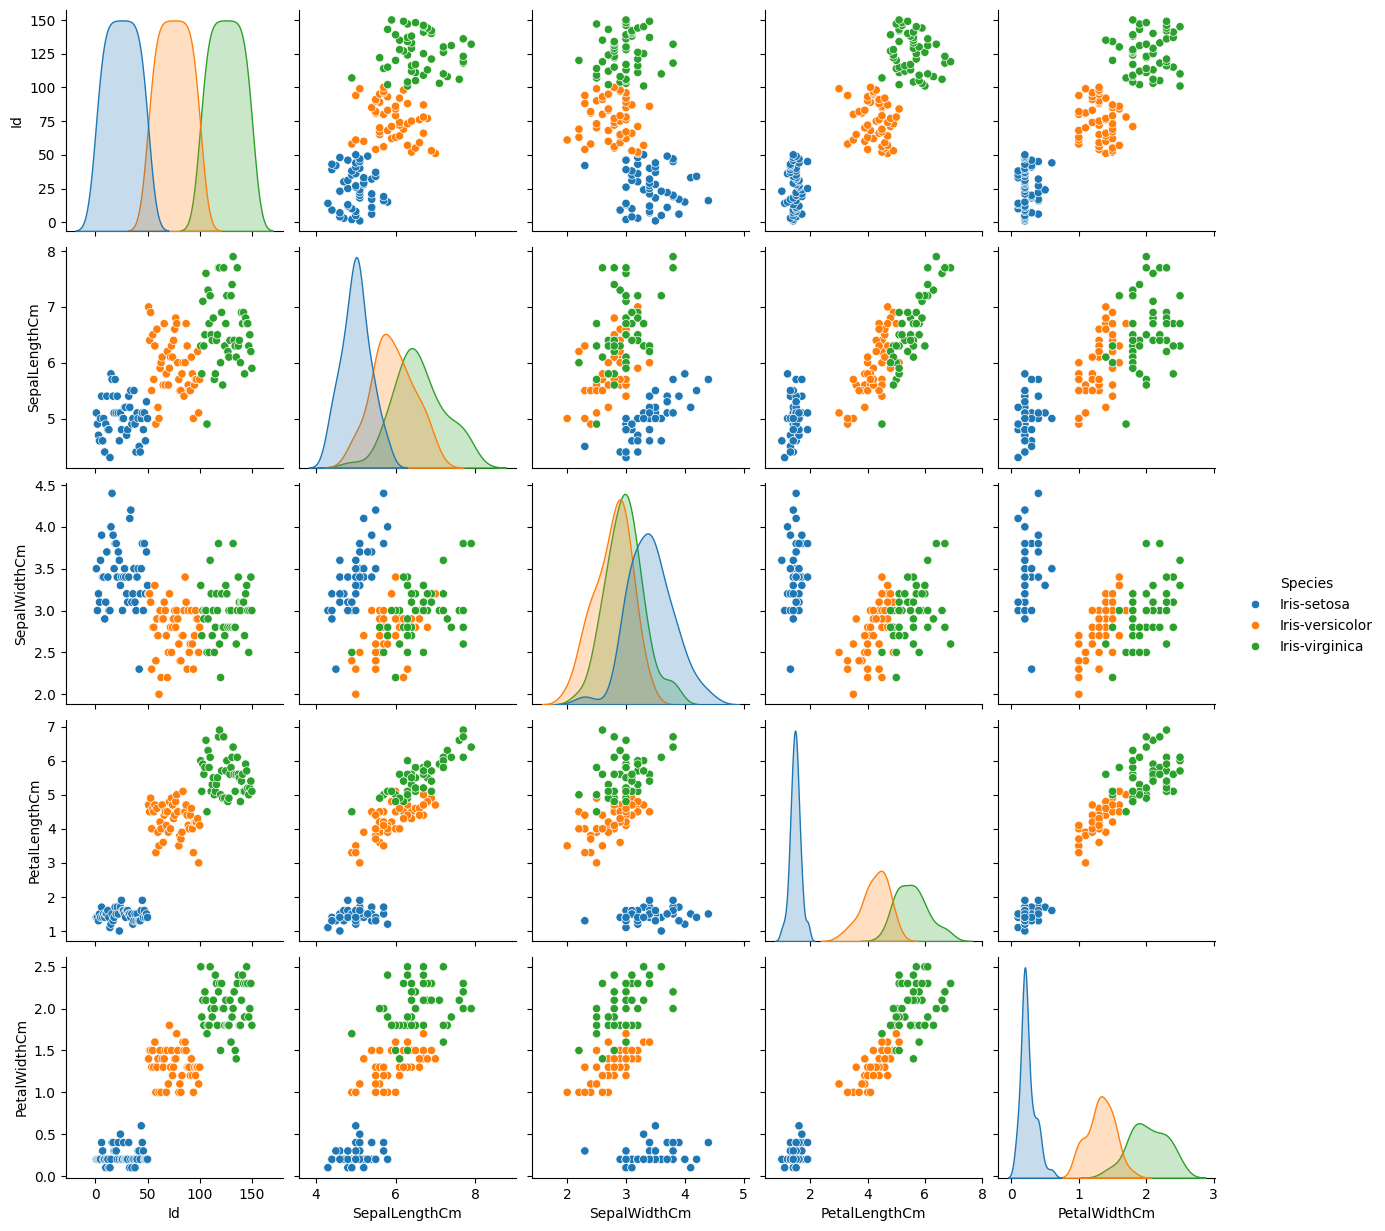

In [28]:
# Pair Plot

sns.pairplot(df, hue="Species")

plt.show()

### Insight

The exploratory data analysis shows that petal length and petal width are the most important features for distinguishing between the three Iris species. The pair plot and correlation heatmap provide a clear visualization of the relationships among the flower measurements.

## Step 5: Prepare the Dataset

In [29]:
# Features (Input)

X = df.drop(["Id", "Species"], axis=1)

# Target (Output)

y = df["Species"]

In [30]:
# Split the dataset into Training and Testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
# Display the shape of Training and Testing datasets

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (120, 4)
Testing Data Shape  : (30, 4)


### Insight

The dataset was divided into **80% training data** and **20% testing data**.

The training data is used to train the Machine Learning model, while the testing data is used to evaluate its performance on unseen flower samples.

## Step 6: Train the Machine Learning Model

In [32]:
# Create the Decision Tree Classifier

model = DecisionTreeClassifier(random_state=42)

# Train the model

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### Insight

The Decision Tree Classifier was trained using the training dataset.

The model learned the relationship between the flower measurements and their corresponding Iris species.

## Step 7: Predict the Test Data

In [33]:
# Predict the species for the test dataset

y_pred = model.predict(X_test)

### Insight

The trained Decision Tree model was used to predict the species of flowers in the testing dataset.

These predictions will be compared with the actual species to evaluate the model's performance.

## Step 8: Evaluate Model Performance

In [34]:
# Calculate Model Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 100.0 %


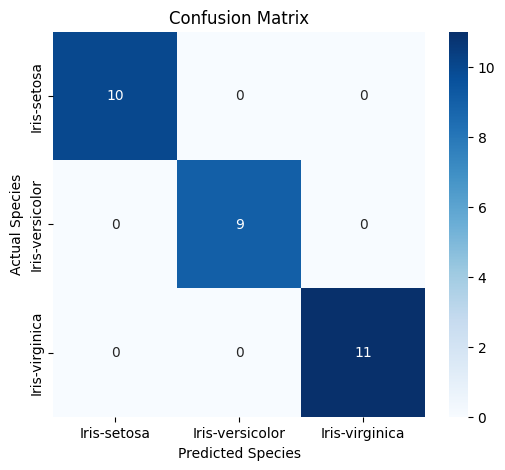

In [35]:
# Display the Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Species")

plt.ylabel("Actual Species")

plt.show()

In [36]:
# Display the Classification Report

print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



### Insight

The Decision Tree Classifier achieved excellent classification performance on the testing dataset.

The evaluation metrics indicate that the model accurately classified the three Iris flower species with high precision, recall, and F1-score.

## Step 9: Predict a New Flower Species

In [37]:
# Predict the species of a new flower

new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("Predicted Species:", prediction[0])

Predicted Species: Iris-setosa


### Insight

The trained model successfully predicted the species of a new flower sample based on its measurements.

This demonstrates the model's ability to classify previously unseen flower data accurately.

## Step 10: Save the Trained Model

In [38]:
# Import Joblib

import joblib

# Save the trained model

joblib.dump(model, "iris_flower_model.pkl")

print("Model saved successfully!")

Model saved successfully!


### Insight

The trained Decision Tree model was saved using Joblib.

Saving the model allows it to be reused for future predictions without retraining.

# Conclusion

This project successfully developed an "Iris Flower Classification System" using the "Decision Tree Classifier".

The project followed a complete Machine Learning workflow, including:

- Data Loading
- Exploratory Data Analysis (EDA)
- Data Preparation
- Model Training
- Model Evaluation
- Prediction
- Model Saving

The trained model achieved excellent classification accuracy, demonstrating the effectiveness of Machine Learning for multiclass classification problems.

This project highlights the practical application of Machine Learning in automatically classifying flower species based on their measurements.